In [ ]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans

train_path = "../data/split/train/train.csv"
test_path  = "../data/split/test/test.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)

df_train["price_per_m2"] = df_train["price"] / df_train["area"]
df_test["price_per_m2"]  = df_test["price"]  / df_test["area"]

kmeans = KMeans(n_clusters=3, random_state=42)
df_train["cluster"] = kmeans.fit_predict(df_train[["price_per_m2"]])

df_test["cluster"] = kmeans.predict(df_test[["price_per_m2"]])

cluster_0_train = df_train[df_train["cluster"] == 0]
cluster_1_train = df_train[df_train["cluster"] == 1]
cluster_2_train = df_train[df_train["cluster"] == 2]

cluster_0_test = df_test[df_test["cluster"] == 0]
cluster_1_test = df_test[df_test["cluster"] == 1]
cluster_2_test = df_test[df_test["cluster"] == 2]

print("Số lượng mỗi cluster (train):")
print(df_train["cluster"].value_counts())

print("\nSố lượng mỗi cluster (test):")
print(df_test["cluster"].value_counts())

Số lượng mỗi cluster (train):
cluster
0     488
1    1001
2     110
3       1
Name: count, dtype: int64

Số lượng mỗi cluster (test):
cluster
0    117
1    256
2     28
Name: count, dtype: int64


In [35]:
# Mapping địa chỉ -> cluster (mode)
address_cluster_map = (
    df_train.groupby('address')['cluster']
        .agg(lambda s: s.mode().iat[0] if not s.mode().empty else -1)
        .reset_index()
        .rename(columns={'cluster':'cluster_mode'})
)
print('\n=== Địa chỉ thuộc cluster nào (mode) ===')
print(address_cluster_map)




=== Địa chỉ thuộc cluster nào (mode) ===
       address  cluster_mode
0   bình chánh             1
1   bình thạnh             0
2     bình tân             1
3      cần giờ             0
4       gò vấp             0
5       nhà bè             1
6    phú nhuận             1
7       quận 1             0
8      quận 10             1
9      quận 11             2
10     quận 12             1
11      quận 2             0
12      quận 3             1
13      quận 4             1
14      quận 5             1
15      quận 6             1
16      quận 7             1
17      quận 8             1
18      quận 9             1
19     thủ đức             1
20    tân bình             1
21     tân phú             1


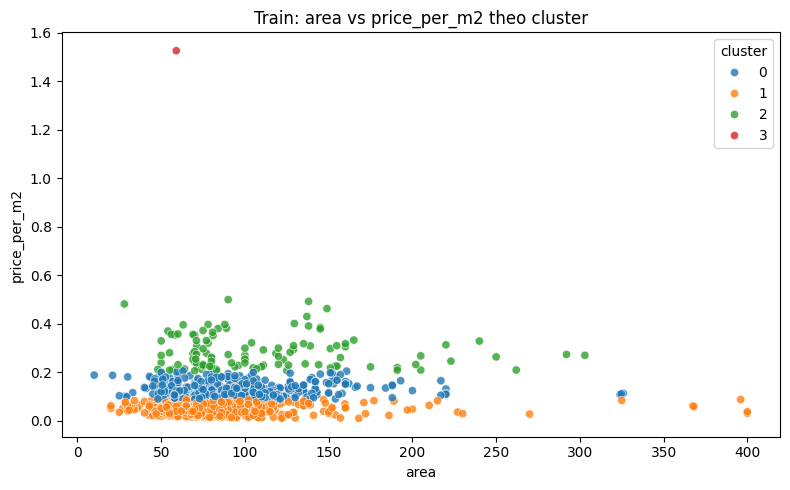

C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_22828\3577177283.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10')


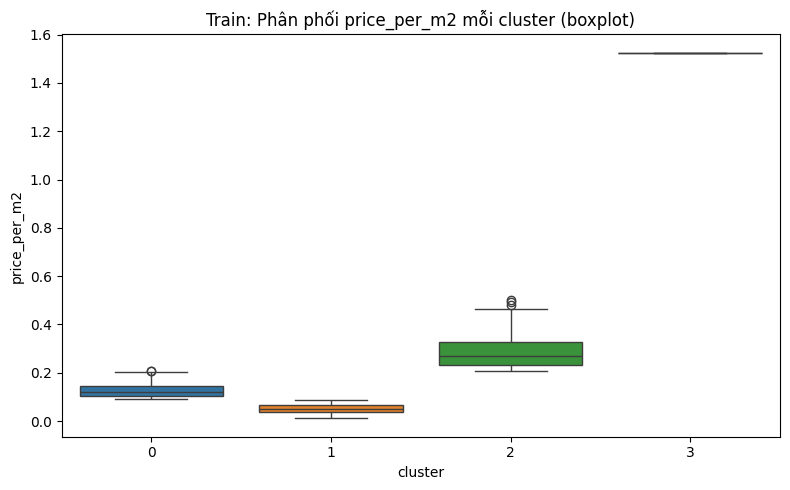

C:\Users\Duong Thanh Loc\AppData\Local\Temp\ipykernel_22828\3577177283.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10', cut=0)


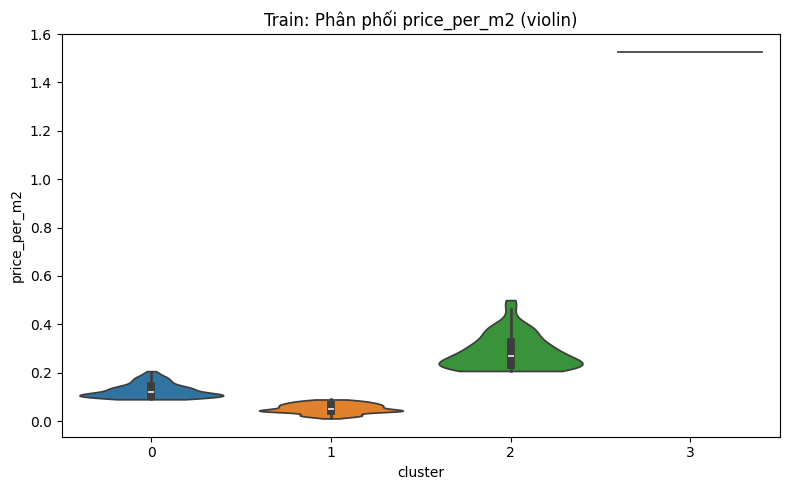

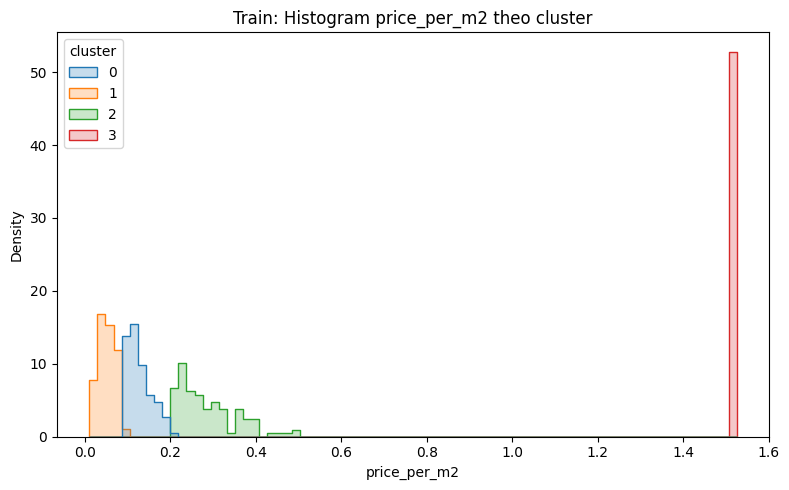


Tóm tắt price_per_m2 theo cluster:
         count      mean    median       min       max
cluster                                               
0          488  0.127321  0.119100  0.089974  0.206349
1         1001  0.052194  0.050746  0.010863  0.089130
2          110  0.286850  0.270000  0.207143  0.500000
3            1  1.525424  1.525424  1.525424  1.525424


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize clusters theo price_per_m2 (train)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df_train, x='area', y='price_per_m2', hue='cluster', palette='tab10', alpha=0.8)
plt.title('Train: area vs price_per_m2 theo cluster')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10')
plt.title('Train: Phân phối price_per_m2 mỗi cluster (boxplot)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.violinplot(data=df_train, x='cluster', y='price_per_m2', palette='tab10', cut=0)
plt.title('Train: Phân phối price_per_m2 (violin)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(data=df_train, x='price_per_m2', hue='cluster', element='step', stat='density', common_norm=False, palette='tab10')
plt.title('Train: Histogram price_per_m2 theo cluster')
plt.tight_layout()
plt.show()

cluster_stats = df_train.groupby('cluster')['price_per_m2'].agg(['count','mean','median','min','max']).sort_index()
print('\nTóm tắt price_per_m2 theo cluster:')
print(cluster_stats)


In [37]:
from sklearn.preprocessing import StandardScaler
for df in (df_train, df_test):
    drop_cols = [c for c in ['address','region'] if c in df.columns]
    if drop_cols:
        df.drop(columns=drop_cols, inplace=True)

scaler_area = StandardScaler()
df_train['area'] = scaler_area.fit_transform(df_train[['area']])
df_test['area']  = scaler_area.transform(df_test[['area']])

In [ ]:
import torch

def build_dataset(df):
    feature_cols = ["area", "bedrooms", "bathrooms"]
    X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y = torch.tensor(df[["price"]].values, dtype=torch.float32)
    return X, y

X0_train, y0_train = build_dataset(cluster_0_train)
X1_train, y1_train = build_dataset(cluster_1_train)
X2_train, y2_train = build_dataset(cluster_2_train)

X0_test, y0_test = build_dataset(cluster_0_test)
X1_test, y1_test = build_dataset(cluster_1_test)
X2_test, y2_test = build_dataset(cluster_2_test)


In [ ]:
import torch.nn as nn
from sklearn.metrics import r2_score, mean_squared_error

def train_cluster_model(X_train, y_train, epochs=3000, lr=1e-3):
    model = nn.Linear(X_train.shape[1], 1)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for ep in range(epochs):
        pred = model(X_train)
        loss = criterion(pred, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    return model


def evaluate_cluster_model(model, X_test, y_test):
    with torch.no_grad():
        y_pred = model(X_test).cpu().numpy()

    y_true = y_test.cpu().numpy()

    r2 = r2_score(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    return r2, rmse



In [ ]:
models = {}

for idx, (Xt_tr, Yt_tr, Xt_te, Yt_te) in enumerate([
    (X0_train, y0_train, X0_test, y0_test),
    (X1_train, y1_train, X1_test, y1_test),
    (X2_train, y2_train, X2_test, y2_test)
]):
    
    print(f"\n=== TRAINING CLUSTER {idx} ===")
    model = train_cluster_model(Xt_tr, Yt_tr)

    r2, rmse = evaluate_cluster_model(model, Xt_te, Yt_te)

    models[idx] = model
    print(f"Cluster {idx}: R² = {r2:.4f} | RMSE = {rmse:.4f}")


=== TRAINING CLUSTER 0 ===
Cluster 0: R² = 0.7201 | RMSE = 4.1685

=== TRAINING CLUSTER 1 ===
Cluster 0: R² = 0.7201 | RMSE = 4.1685

=== TRAINING CLUSTER 1 ===
Cluster 1: R² = 0.4714 | RMSE = 1.5157

=== TRAINING CLUSTER 2 ===
Cluster 1: R² = 0.4714 | RMSE = 1.5157

=== TRAINING CLUSTER 2 ===
Cluster 2: R² = 0.8550 | RMSE = 8.1942

=== TRAINING CLUSTER 3 ===
Cluster 2: R² = 0.8550 | RMSE = 8.1942

=== TRAINING CLUSTER 3 ===


ValueError: Found array with 0 sample(s) (shape=(0, 1)) while a minimum of 1 is required.